In [13]:
from fuzzy_lr import FuzzyLRController, FuzzyLRConfig, trimf, trapmf, gbellmf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

In [14]:
def plot_membership_functions():
    """Tüm üyelik fonksiyonlarını göster"""
    
    ctrl = FuzzyLRController(base_lr=0.001, cfg=FuzzyLRConfig())
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Fuzzy Üyelik Fonksiyonları', fontsize=16, fontweight='bold')
    
    # --- DELTA LOSS ---
    ax = axes[0, 0]
    dl_range = np.linspace(-1.2, 0.8, 300)
    dl_vals = {'hizla_azalan': [], 'az_azalan': [], 'durdu': [], 'artan': []}
    
    for dl in dl_range:
        mf = ctrl._mf_delta_loss(dl)
        for key in dl_vals.keys():
            dl_vals[key].append(mf[key])
    
    for key, vals in dl_vals.items():
        ax.plot(dl_range, vals, linewidth=2, label=key)
    
    ax.set_xlabel('Delta Loss', fontsize=12)
    ax.set_ylabel('Üyelik Derecesi', fontsize=12)
    ax.set_title('Delta Loss Üyelik Fonksiyonları', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])
    
    # --- GRADIENT NORM ---
    ax = axes[0, 1]
    gn_range = np.linspace(0, 12, 300)
    gn_vals = {'kucuk': [], 'orta': [], 'buyuk': []}
    
    for gn in gn_range:
        mf = ctrl._mf_grad_norm(gn)
        for key in gn_vals.keys():
            gn_vals[key].append(mf[key])
    
    for key, vals in gn_vals.items():
        ax.plot(gn_range, vals, linewidth=2, label=key)
    
    ax.set_xlabel('Gradient Norm (Normalized)', fontsize=12)
    ax.set_ylabel('Üyelik Derecesi', fontsize=12)
    ax.set_title('Gradient Norm Üyelik Fonksiyonları', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])
    
    # --- PLATEAU STEPS ---
    ax = axes[1, 0]
    pl_range = np.linspace(0, 10, 300)
    pl_vals = {'kisa': [], 'orta': [], 'uzun': []}
    
    for pl in pl_range:
        mf = ctrl._mf_plateau(pl)
        for key in pl_vals.keys():
            pl_vals[key].append(mf[key])
    
    for key, vals in pl_vals.items():
        ax.plot(pl_range, vals, linewidth=2, label=key)
    
    ax.set_xlabel('Plateau Steps (Epochs)', fontsize=12)
    ax.set_ylabel('Üyelik Derecesi', fontsize=12)
    ax.set_title('Plateau Üyelik Fonksiyonları', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])
    
    plt.tight_layout()
    plt.savefig('fuzzy_membership_functions.png', dpi=300, bbox_inches='tight')
    print("✅ Grafik kaydedildi: fuzzy_membership_functions.png")
    plt.show()

In [15]:
def plot_fuzzy_surface():
    """Delta Loss ve Gradient Norm'a göre Scale çıktısını 3D göster"""
    
    ctrl = FuzzyLRController(base_lr=0.001, cfg=FuzzyLRConfig())
    
    # Grid oluştur
    dl_range = np.linspace(-1.0, 0.6, 50)
    gn_range = np.linspace(0.5, 11, 50)
    DL, GN = np.meshgrid(dl_range, gn_range)
    
    # Her nokta için scale hesapla
    SCALE = np.zeros_like(DL)
    for i in range(DL.shape[0]):
        for j in range(DL.shape[1]):
            scale = ctrl.infer_scale(
                dl=float(DL[i, j]),      # ✅ Explicit float cast
                gn=float(GN[i, j]),      # ✅ Explicit float cast
                da=0.0, 
                psteps=0
            )
            SCALE[i, j] = scale
    
    # 3D Plot
    fig = plt.figure(figsize=(14, 10))
    
    # Subplot 1: 3D Surface
    ax1 = fig.add_subplot(121, projection='3d')
    
    # ✅ Değişiklik: contourf kullan (daha stabil)
    surf = ax1.plot_surface(
        np.asarray(DL), 
        np.asarray(GN), 
        np.asarray(SCALE), 
        cmap='coolwarm',  # ✅ cm. kaldırıldı
        linewidth=0, 
        antialiased=True, 
        alpha=0.9,
        rstride=1,  # ✅ Eklendi
        cstride=1   # ✅ Eklendi
    )
    
    ax1.set_xlabel('Delta Loss', fontsize=11)
    ax1.set_ylabel('Gradient Norm', fontsize=11)
    ax1.set_zlabel('Scale', fontsize=11)
    ax1.set_title('Fuzzy Kontrol Yüzeyi (3D)', fontweight='bold', fontsize=13)
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)
    
    plt.tight_layout()
    plt.savefig('fuzzy_control_surface.png', dpi=300, bbox_inches='tight')
    print("✅ Grafik kaydedildi: fuzzy_control_surface.png")
    plt.show()

In [16]:
def plot_scenario_analysis():
    """Farklı senaryolarda fuzzy sistem nasıl tepki veriyor?"""
    
    ctrl = FuzzyLRController(base_lr=0.001, cfg=FuzzyLRConfig())
    
    # Senaryolar
    scenarios = {
        'İyi Öğrenme': {'dl': -0.5, 'gn': 6.5, 'pl': 0},
        'Yavaş İyileşme': {'dl': -0.05, 'gn': 7.0, 'pl': 2},
        'Plateau': {'dl': 0.0, 'gn': 6.0, 'pl': 8},
        'Loss Artışı': {'dl': 0.3, 'gn': 9.0, 'pl': 5},
        'Gradient Patlaması': {'dl': 0.1, 'gn': 11.0, 'pl': 1},
        'Optimal Durum': {'dl': -0.2, 'gn': 6.5, 'pl': 0},
    }
    
    results = []
    for name, params in scenarios.items():
        scale = ctrl.infer_scale(params['dl'], params['gn'], 0.0, params['pl'])
        lr = ctrl.lr_from_scale(scale)
        results.append({
            'Senaryo': name,
            'Delta Loss': params['dl'],
            'Grad Norm': params['gn'],
            'Plateau': params['pl'],
            'Scale': scale,
            'LR': lr
        })
    
    # Görselleştir
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart: Scale değerleri
    names = [r['Senaryo'] for r in results]
    scales = [r['Scale'] for r in results]
    colors = ['green' if s > 1.0 else 'red' if s < 1.0 else 'gray' for s in scales]
    
    ax1.barh(names, scales, color=colors, alpha=0.7, edgecolor='black')
    ax1.axvline(x=1.0, color='black', linestyle='--', linewidth=2, label='Base Scale')
    ax1.set_xlabel('Scale Değeri', fontsize=12)
    ax1.set_title('Senaryo Bazlı Scale Kararları', fontweight='bold', fontsize=13)
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)
    
    # Table: Detaylı bilgi
    ax2.axis('tight')
    ax2.axis('off')
    table_data = [[r['Senaryo'], f"{r['Delta Loss']:.2f}", f"{r['Grad Norm']:.1f}", 
                   f"{r['Plateau']}", f"{r['Scale']:.3f}", f"{r['LR']:.6f}"] 
                  for r in results]
    
    table = ax2.table(cellText=table_data, 
                     colLabels=['Senaryo', 'ΔLoss', 'GradNorm', 'Plateau', 'Scale', 'LR'],
                     cellLoc='center', loc='center', 
                     colWidths=[0.25, 0.12, 0.12, 0.12, 0.12, 0.15])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Header'ı vurgula
    for i in range(6):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Satırları renklendir
    for i, scale in enumerate(scales, start=1):
        color = '#C8E6C9' if scale > 1.0 else '#FFCDD2' if scale < 1.0 else '#E0E0E0'
        for j in range(6):
            table[(i, j)].set_facecolor(color)
    
    ax2.set_title('Detaylı Senaryo Analizi', fontweight='bold', fontsize=13, pad=20)
    
    plt.tight_layout()
    plt.savefig('fuzzy_scenario_analysis.png', dpi=300, bbox_inches='tight')
    print("✅ Grafik kaydedildi: fuzzy_scenario_analysis.png")
    plt.show()

In [17]:
def plot_fuzzy_inference_example():
    """Tek bir örnek için fuzzy çıkarım sürecini göster"""
    
    ctrl = FuzzyLRController(base_lr=0.001, cfg=FuzzyLRConfig())
    
    # Örnek girdi
    dl_test = -0.3  # Loss hızla azalıyor
    gn_test = 8.5   # Gradient biraz yüksek
    pl_test = 2     # Plateau yok
    
    # Üyelik dereceleri
    DL = ctrl._mf_delta_loss(dl_test)
    GN = ctrl._mf_grad_norm(gn_test)
    PL = ctrl._mf_plateau(pl_test)
    
    # Kurallar ve ağırlıkları
    rules = [
        ("Loss hızla azalıyor", min(DL["hizla_azalan"], 1.0), 1.1),
        ("Loss az azalıyor + Grad küçük", min(DL["az_azalan"], GN["kucuk"]), 1.08),
        ("Loss durdu + Grad büyük", min(DL["durdu"], GN["buyuk"]), 0.94),
        ("Loss artıyor + Grad büyük", min(DL["artan"], GN["buyuk"]), 0.94),
        ("Plateau uzun + Loss durdu + Grad küçük", min(PL["uzun"], DL["durdu"], GN["kucuk"]), 1.10),
    ]
    
    # Grafik
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Fuzzy Çıkarım Süreci\nGirdi: ΔLoss={dl_test}, GradNorm={gn_test}, Plateau={pl_test}', 
                 fontsize=16, fontweight='bold')
    
    # Panel 1: Delta Loss aktivasyonu
    ax = axes[0, 0]
    dl_range = np.linspace(-1.2, 0.8, 300)
    for key in DL.keys():
        vals = [ctrl._mf_delta_loss(x)[key] for x in dl_range]
        ax.plot(dl_range, vals, linewidth=2, label=key, alpha=0.5)
    
    ax.axvline(x=dl_test, color='red', linestyle='--', linewidth=2, label=f'Girdi: {dl_test}')
    
    # Aktif üyelikleri vurgula
    for key, val in DL.items():
        if val > 0.01:
            ax.plot(dl_test, val, 'ro', markersize=12)
            ax.text(dl_test + 0.05, val, f'{key}\n({val:.2f})', fontsize=9)
    
    ax.set_xlabel('Delta Loss')
    ax.set_ylabel('Üyelik Derecesi')
    ax.set_title('Delta Loss Aktivasyonu')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Panel 2: Gradient Norm aktivasyonu
    ax = axes[0, 1]
    gn_range = np.linspace(0, 12, 300)
    for key in GN.keys():
        vals = [ctrl._mf_grad_norm(x)[key] for x in gn_range]
        ax.plot(gn_range, vals, linewidth=2, label=key, alpha=0.5)
    
    ax.axvline(x=gn_test, color='red', linestyle='--', linewidth=2, label=f'Girdi: {gn_test}')
    
    for key, val in GN.items():
        if val > 0.01:
            ax.plot(gn_test, val, 'ro', markersize=12)
            ax.text(gn_test + 0.3, val, f'{key}\n({val:.2f})', fontsize=9)
    
    ax.set_xlabel('Gradient Norm')
    ax.set_ylabel('Üyelik Derecesi')
    ax.set_title('Gradient Norm Aktivasyonu')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Panel 3: Aktif kurallar ve ağırlıkları
    ax = axes[1, 0]
    ax.axis('off')
    
    active_rules = [(name, weight, scale) for name, weight, scale in rules if weight > 0.01]
    
    table_data = []
    for i, (name, weight, scale) in enumerate(active_rules, 1):
        table_data.append([f"Kural {i}", name, f"{weight:.3f}", f"{scale:.3f}", f"{weight*scale:.3f}"])
    
    # Fuzzy çıkarım hesaplama
    num = sum(w * s for _, w, s in active_rules)
    den = sum(w for _, w, s in active_rules)
    final_scale = num / (den + 1e-12)
    
    table_data.append(["", "TOPLAM", f"{den:.3f}", "", f"{num:.3f}"])
    table_data.append(["", "SONUÇ", "", "", f"{final_scale:.3f}"])
    
    table = ax.table(cellText=table_data,
                    colLabels=['#', 'Kural', 'Ağırlık (w)', 'Scale (z)', 'w×z'],
                    cellLoc='left', loc='center',
                    colWidths=[0.08, 0.45, 0.12, 0.12, 0.12])
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.5)
    
    # Header
    for i in range(5):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Sonuç satırı
    for i in range(5):
        table[(len(table_data), i)].set_facecolor('#FFC107')
        table[(len(table_data), i)].set_text_props(weight='bold')
    
    ax.set_title('Aktif Kurallar ve Çıkarım', fontweight='bold', fontsize=13, pad=20)
    
    # Panel 4: Defuzzification görselleştirme
    ax = axes[1, 1]
    
    scale_range = np.linspace(0.5, 1.5, 300)
    
    # Her kuralın katkısı (kesik üçgenler)
    colors = plt.cm.Set3(np.linspace(0, 1, len(active_rules)))
    for i, (name, weight, scale_val) in enumerate(active_rules):
        # Üçgen membership fonksiyonu (basitleştirilmiş)
        triangle = np.maximum(0, 1 - np.abs(scale_range - scale_val) / 0.1)
        clipped = np.minimum(triangle, weight)  # Kural ağırlığında kes
        ax.fill_between(scale_range, 0, clipped, alpha=0.5, color=colors[i], 
                       label=f'Kural {i+1} (w={weight:.2f})')
    
    # Center of Gravity (CoG) çizgisi
    ax.axvline(x=final_scale, color='red', linestyle='-', linewidth=3, 
              label=f'Sonuç (CoG): {final_scale:.3f}')
    ax.axvline(x=1.0, color='black', linestyle='--', linewidth=2, alpha=0.5, label='Base (1.0)')
    
    ax.set_xlabel('Scale Değeri')
    ax.set_ylabel('Üyelik Derecesi (Kesilmiş)')
    ax.set_title('Defuzzification (Center of Gravity)', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.85, 1.15])
    
    plt.tight_layout()
    plt.savefig('fuzzy_inference_process.png', dpi=300, bbox_inches='tight')
    print("✅ Grafik kaydedildi: fuzzy_inference_process.png")
    plt.show()
    
    print(f"\n{'='*60}")
    print(f"FUZZY ÇIKARIM SONUCU")
    print(f"{'='*60}")
    print(f"Girdi: ΔLoss={dl_test}, GradNorm={gn_test}, Plateau={pl_test}")
    print(f"Aktif Kural Sayısı: {len(active_rules)}")
    print(f"Final Scale: {final_scale:.4f}")
    print(f"Final LR: {ctrl.lr_from_scale(final_scale):.6f}")
    print(f"{'='*60}\n")

FUZZY LEARNING RATE CONTROLLER - VİZUALİZASYON

1. Üyelik fonksiyonları çiziliyor...
✅ Grafik kaydedildi: fuzzy_membership_functions.png


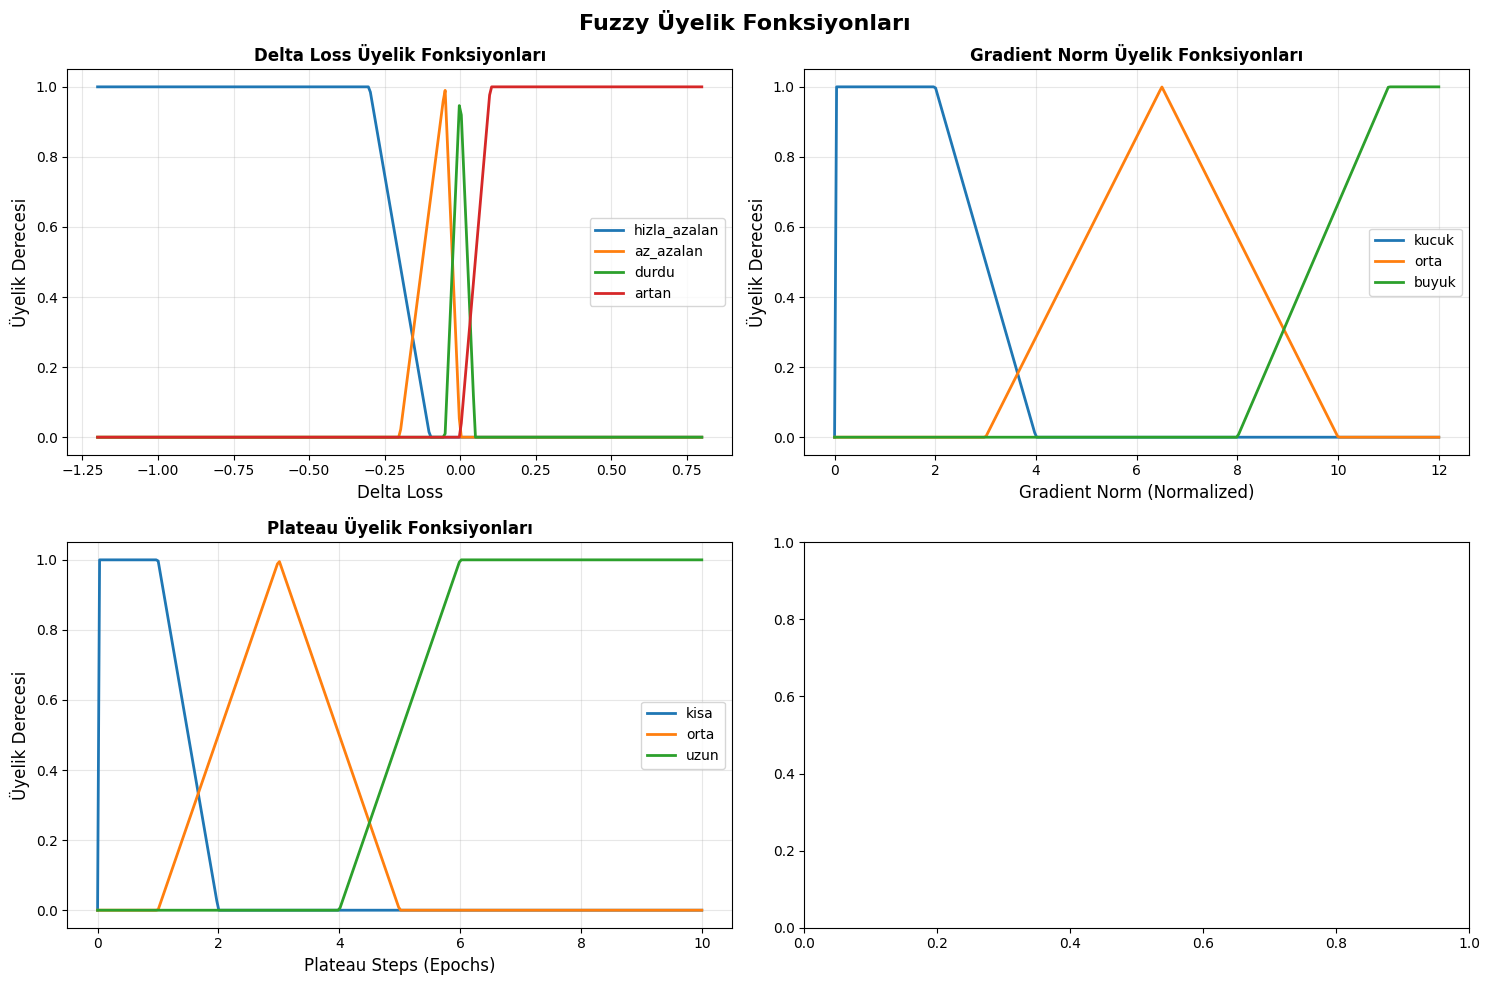


Fuzzy çıkarım süreci örneği çiziliyor...
✅ Grafik kaydedildi: fuzzy_inference_process.png


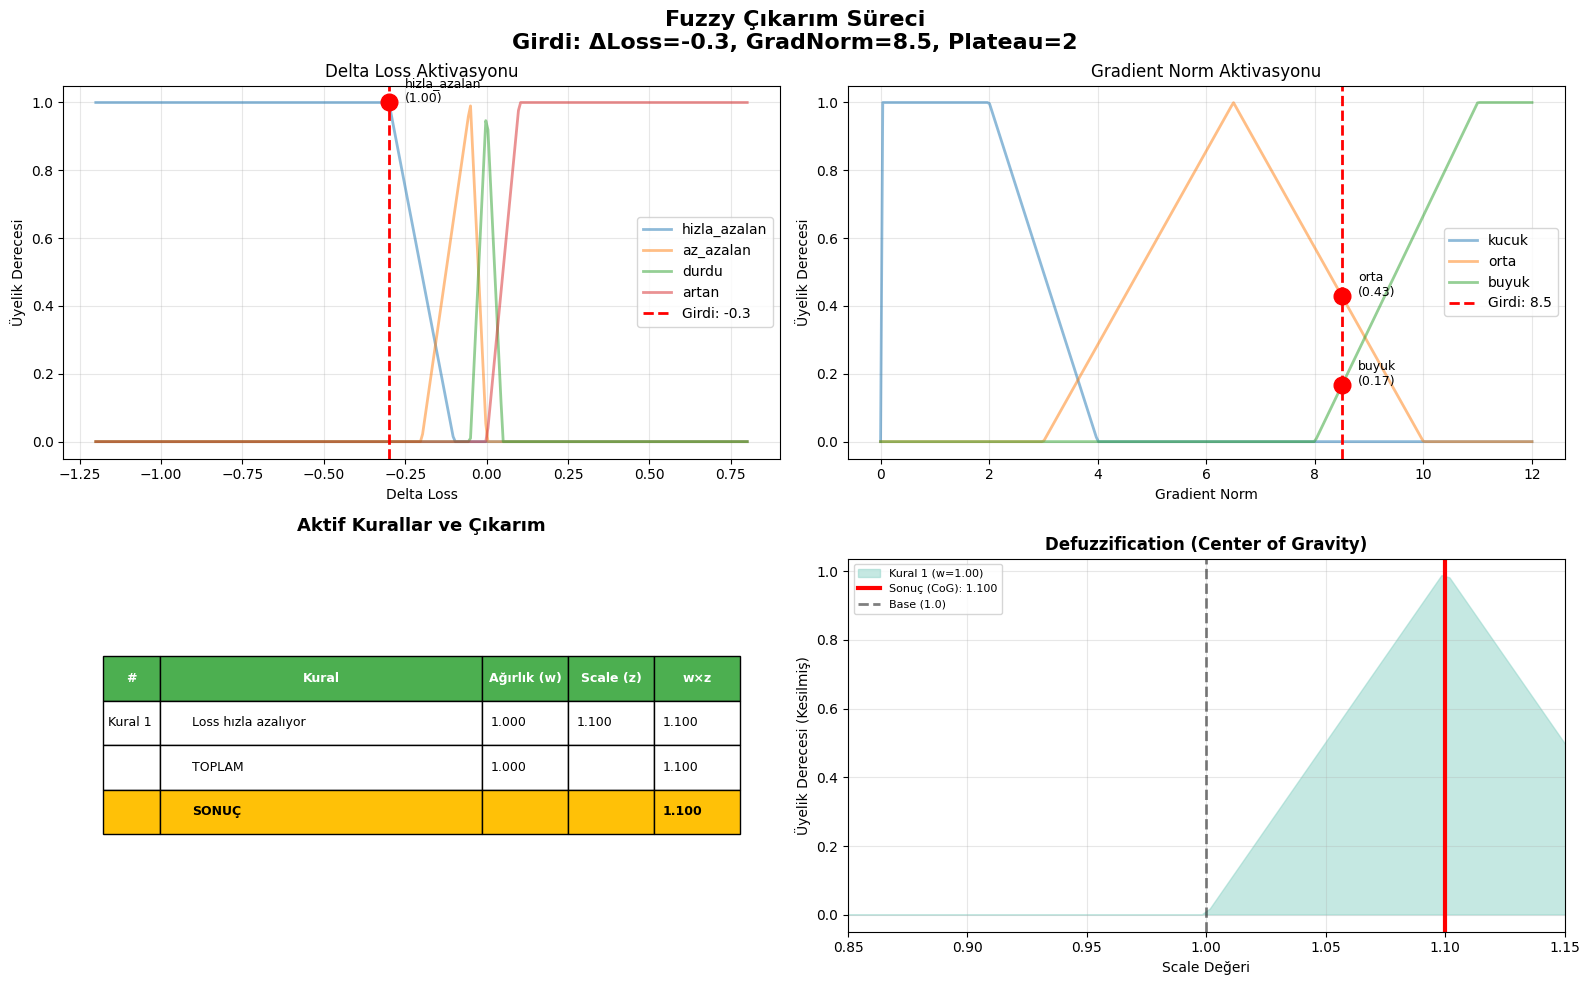


FUZZY ÇIKARIM SONUCU
Girdi: ΔLoss=-0.3, GradNorm=8.5, Plateau=2
Aktif Kural Sayısı: 1
Final Scale: 1.1000
Final LR: 0.001100


2. 3D kontrol yüzeyi çiziliyor...
✅ Grafik kaydedildi: fuzzy_control_surface.png


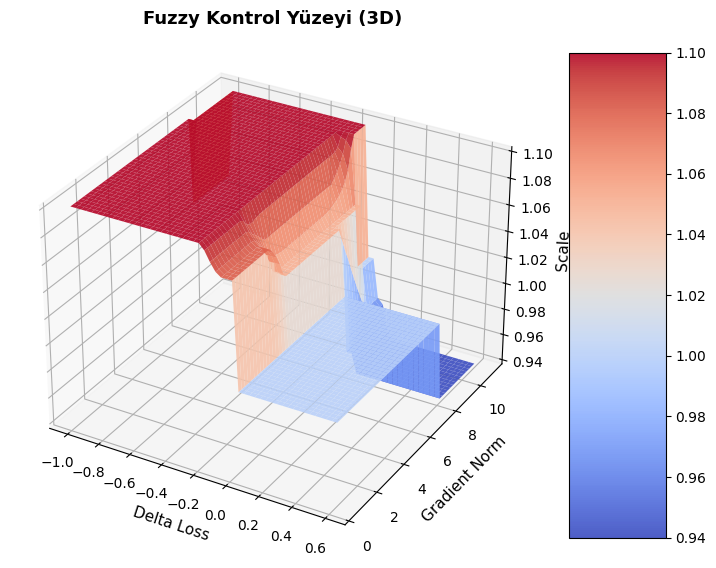


3. Senaryo analizi çiziliyor...
✅ Grafik kaydedildi: fuzzy_scenario_analysis.png


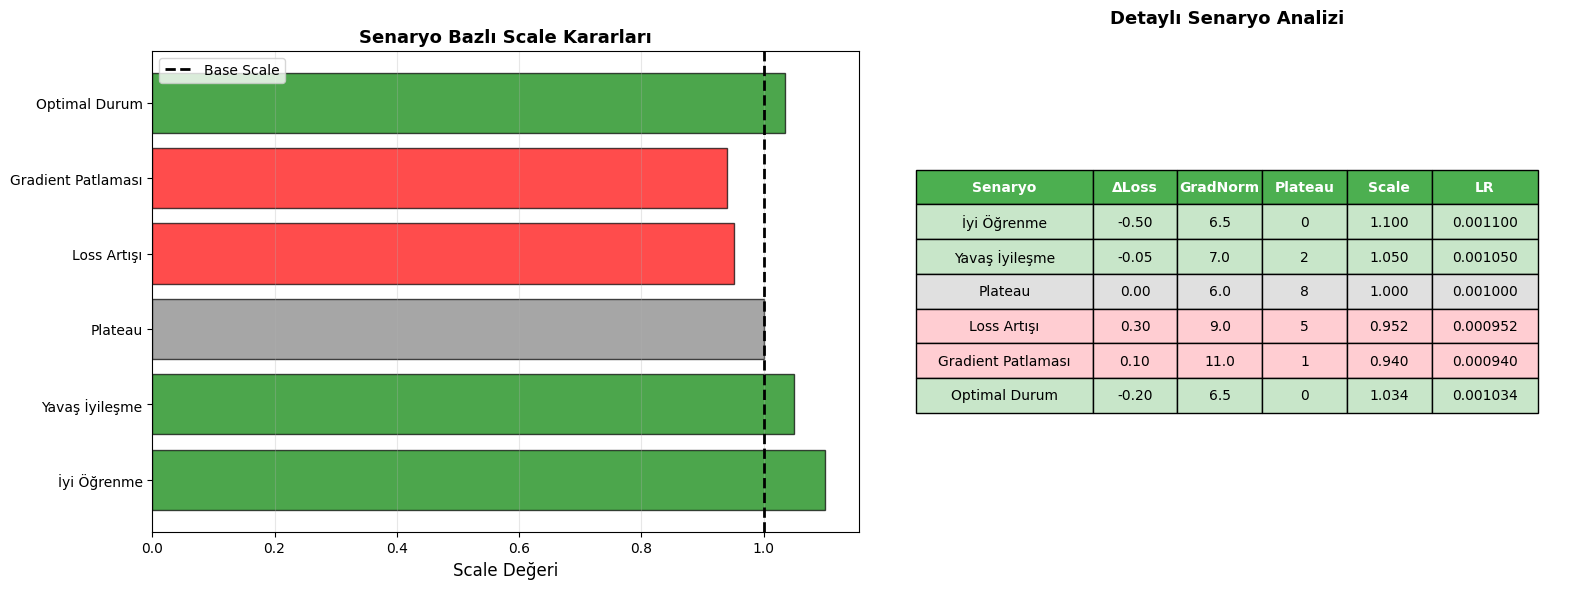


✅ TÜM GRAFİKLER OLUŞTURULDU!

Kaydedilen dosyalar:
  - fuzzy_membership_functions.png
  - fuzzy_control_surface.png
  - fuzzy_scenario_analysis.png
  - fuzzy_real_training_analysis.png (eğitim sonrası)


In [18]:
print("=" * 60)
print("FUZZY LEARNING RATE CONTROLLER - VİZUALİZASYON")
print("=" * 60)

print("\n1. Üyelik fonksiyonları çiziliyor...")
plot_membership_functions()

print("\nFuzzy çıkarım süreci örneği çiziliyor...")
plot_fuzzy_inference_example()

print("\n2. 3D kontrol yüzeyi çiziliyor...")
plot_fuzzy_surface()

print("\n3. Senaryo analizi çiziliyor...")
plot_scenario_analysis()

print("\n" + "=" * 60)
print("✅ TÜM GRAFİKLER OLUŞTURULDU!")
print("=" * 60)
print("\nKaydedilen dosyalar:")
print("  - fuzzy_membership_functions.png")
print("  - fuzzy_control_surface.png")
print("  - fuzzy_scenario_analysis.png")
print("  - fuzzy_real_training_analysis.png (eğitim sonrası)")

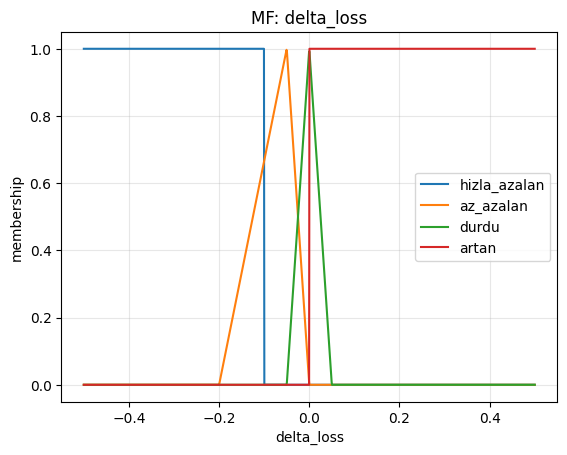

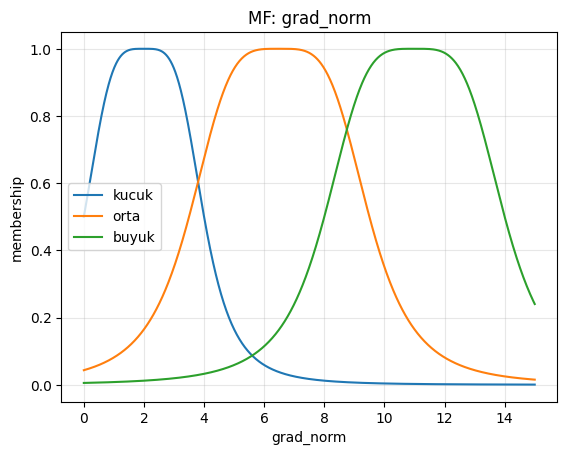

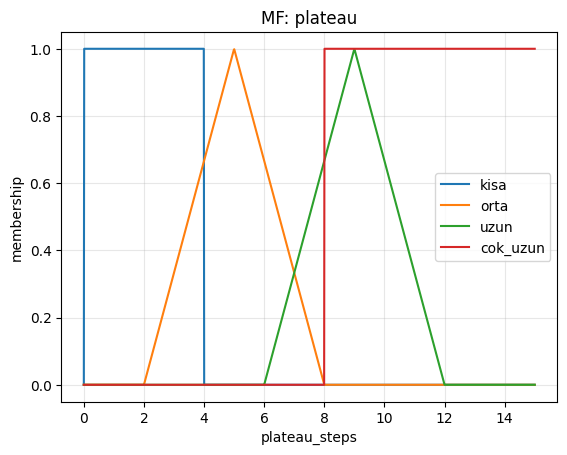

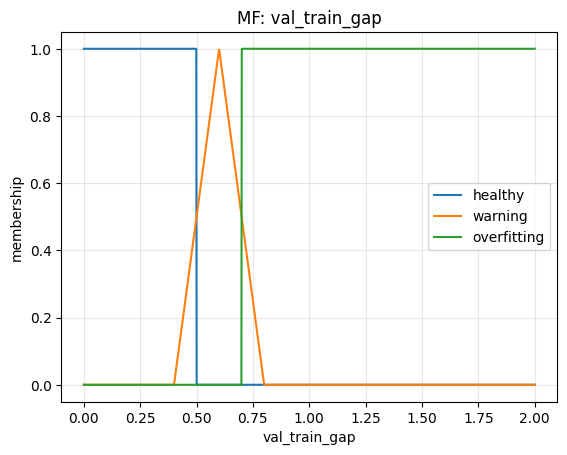

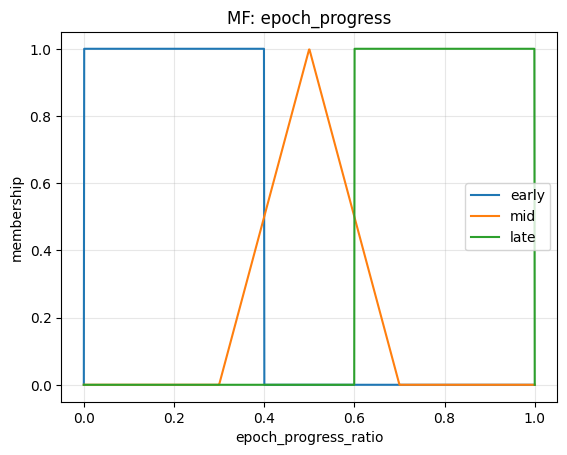

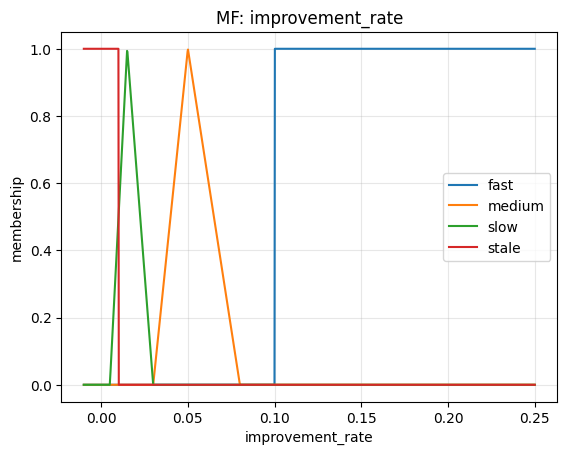

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Membership function primitives
# ----------------------------
def trapmf(x, a, b, c, d):
    """
    Trapezoidal membership function with points (a, b, c, d).
    Handles shoulder cases where a==b or c==d.
    """
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)

    # Left rising edge
    if b > a:
        idx = (x > a) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)
    else:
        # a == b => left shoulder, jump to 1 at x >= b
        y[x >= b] = 1.0

    # Top (plateau)
    y[(x >= b) & (x <= c)] = 1.0

    # Right falling edge
    if d > c:
        idx = (x > c) & (x < d)
        y[idx] = np.maximum(y[idx], (d - x[idx]) / (d - c))
    else:
        # c == d => right shoulder, stay 1 until c then drop
        y[x <= c] = np.maximum(y[x <= c], 1.0)

    # Outside [a, d] is 0
    y[(x <= a) | (x >= d)] = 0.0
    # Fix shoulders again (numerical safety)
    y = np.clip(y, 0.0, 1.0)
    return y


def trimf(x, a, b, c):
    """
    Triangular membership function with points (a, b, c).
    """
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)

    # Rising
    if b > a:
        idx = (x > a) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)

    # Peak
    y[x == b] = 1.0

    # Falling
    if c > b:
        idx = (x > b) & (x < c)
        y[idx] = (c - x[idx]) / (c - b)

    y = np.clip(y, 0.0, 1.0)
    return y


def gbellmf(x, a, b, c):
    """
    Generalized bell membership function:
    mu(x) = 1 / (1 + |(x-c)/a|^(2b))
    """
    x = np.asarray(x, dtype=float)
    a = float(a)
    b = float(b)
    c = float(c)
    # a must be > 0
    if a <= 0:
        raise ValueError("gbellmf: 'a' must be > 0")
    return 1.0 / (1.0 + np.abs((x - c) / a) ** (2.0 * b))


# ----------------------------
# Your membership function sets (translated to pure functions)
# ----------------------------
def mf_delta_loss(dl):
    return {
        "hizla_azalan": trapmf(dl, -999, -999, -0.3, -0.1),
        "az_azalan":    trimf(dl, -0.2, -0.05, 0.0),
        "durdu":        trimf(dl, -0.05, 0.0, 0.05),
        "artan":        trapmf(dl, 0.0, 0.1, 999, 999),
    }

def mf_grad_norm(gn):
    return {
        "kucuk": gbellmf(gn, a=2.0, b=2, c=2.0),
        "orta":  gbellmf(gn, a=3.0, b=2, c=6.5),
        "buyuk": gbellmf(gn, a=3.0, b=2, c=11.0),
    }

def mf_plateau(p):
    return {
        "kisa":      trapmf(p, 0, 0, 2, 4),
        "orta":      trimf(p, 2, 5, 8),
        "uzun":      trimf(p, 6, 9, 12),
        "cok_uzun":  trapmf(p, 8, 12, 999, 999),
    }

def mf_val_train_gap(gap, overfitting_threshold=1.0):
    return {
        "healthy":     trapmf(gap, -999, -999, 0.3, 0.5),
        "warning":     trimf(gap, 0.4, 0.6, 0.8),
        "overfitting": trapmf(gap, 0.7, overfitting_threshold, 999, 999),
    }

def mf_epoch_progress(ratio):
    return {
        "early":  trapmf(ratio, 0, 0, 0.2, 0.4),
        "mid":    trimf(ratio, 0.3, 0.5, 0.7),
        "late":   trapmf(ratio, 0.6, 0.8, 1.0, 1.0),
    }

def mf_improvement_rate(rate):
    return {
        "fast":   trapmf(rate, 0.1, 0.2, 999, 999),
        "medium": trimf(rate, 0.03, 0.05, 0.08),
        "slow":   trimf(rate, 0.005, 0.015, 0.03),
        "stale":  trapmf(rate, -999, -999, 0.003, 0.01),
    }


# ----------------------------
# Plot helper
# ----------------------------
def plot_mf_set(x, mf_dict, title, xlabel):
    plt.figure()
    for name, y in mf_dict.items():
        plt.plot(x, y, label=name)
    plt.ylim(-0.05, 1.05)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("membership")
    plt.grid(True, alpha=0.3)
    plt.legend()


def plot_all_memberships(
    overfitting_threshold=1.0,
    show=True
):
    """
    Plots all MF groups, each on its own figure.
    Adjust ranges below if you want zoomed-in views.
    """
    # Reasonable plot ranges (zoom in; avoid -999..999)
    x_dl = np.linspace(-0.5, 0.5, 1200)
    x_gn = np.linspace(0, 15, 1200)
    x_p  = np.linspace(0, 15, 1200)
    x_gap = np.linspace(0, max(2.0, overfitting_threshold + 0.5), 1200)
    x_ratio = np.linspace(0, 1, 1200)
    x_rate = np.linspace(-0.01, 0.25, 1200)

    plot_mf_set(x_dl, mf_delta_loss(x_dl), "MF: delta_loss", "delta_loss")
    plot_mf_set(x_gn, mf_grad_norm(x_gn), "MF: grad_norm", "grad_norm")
    plot_mf_set(x_p,  mf_plateau(x_p),    "MF: plateau", "plateau_steps")
    plot_mf_set(x_gap, mf_val_train_gap(x_gap, overfitting_threshold), "MF: val_train_gap", "val_train_gap")
    plot_mf_set(x_ratio, mf_epoch_progress(x_ratio), "MF: epoch_progress", "epoch_progress_ratio")
    plot_mf_set(x_rate, mf_improvement_rate(x_rate), "MF: improvement_rate", "improvement_rate")

    if show:
        plt.show()


# Example usage:
if __name__ == "__main__":
    plot_all_memberships(overfitting_threshold=0.9)